# Comparative Analysis of Machine Learning Models for Highly Imbalanced Credit Card Fraud Detection

## 1. Project Objective
This project builds and evaluates multiple machine learning models to classify credit card transactions as legitimate or fraudulent. The dataset is highly imbalanced (fraud makes up less than 0.2%).
We will focus on Recall and F1-score to evaluate the models' ability to minimize False Negatives.

## 2. Dataset Description
- **Source**: OpenML / Kaggle (Credit Card Fraud Detection Dataset)
- **Size**: 284,807 transactions, 492 frauds.
- **Features**: `Amount`, and 28 PCA-transformed features (`V1` to `V28`).
- **Target**: `Class` (0 = Legitimate, 1 = Fraudulent).

## Imports & Setup

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, roc_auc_score, average_precision_score, RocCurveDisplay, PrecisionRecallDisplay, roc_curve, precision_recall_curve

from sklearn.linear_model import LogisticRegression, SGDClassifier, RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, ExtraTreesClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

from imblearn.over_sampling import SMOTE

# Set visualization style
sns.set_style('whitegrid')
import warnings
warnings.filterwarnings('ignore')

## Data Acquisition
We fetch the dataset from OpenML. This provides the exact same Kaggle dataset without requiring API keys.

In [49]:
# Fetching the dataset
print("Downloading dataset from OpenML...")
data = fetch_openml('creditcard', version=1, as_frame=True, parser='auto')
df = data.frame

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (284807, 30)


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [50]:
# Ensure Class column is integer type
if df['Class'].dtype != 'int64' and df['Class'].dtype != 'int32':
    df['Class'] = df['Class'].astype(int)


## Phase 1: Exploratory Data Analysis (EDA)

Class
0    284315
1       492
Name: count, dtype: int64
Fraudulent ratio: 0.173%


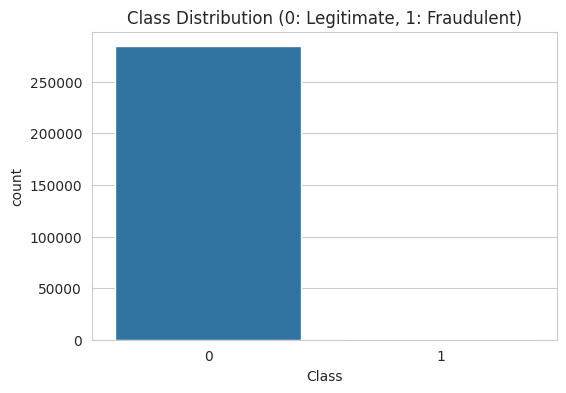

In [51]:
# Class distribution
class_counts = df['Class'].value_counts()
print(class_counts)
print(f"Fraudulent ratio: {class_counts[1] / len(df) * 100:.3f}%")

plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title("Class Distribution (0: Legitimate, 1: Fraudulent)")
plt.show()

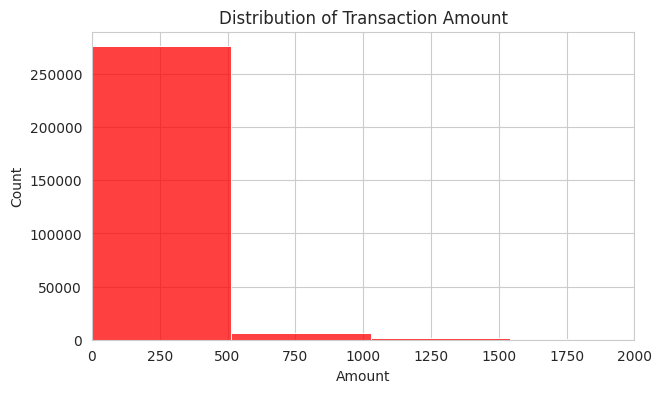

In [52]:
# Amount distribution
fig, ax = plt.subplots(1, 1, figsize=(7, 4))

sns.histplot(df['Amount'], bins=50, color='r')
plt.title('Distribution of Transaction Amount')
plt.xlim([0, 2000]) # Zooming in as most amounts are small
plt.show()

In [53]:
# Check for missing values
print("Missing values in dataset:", df.isnull().sum().max())

Missing values in dataset: 0


## Phase 2: Data Preprocessing
- **Scaling**: We use `RobustScaler` on `Amount` because it is less prone to outliers than `StandardScaler`.
- **Splitting**: 80/20 stratified split.
- **Addressing Imbalance**: We will apply SMOTE to the training set only.

In [54]:
# Scaling
scaler = RobustScaler()
df['scaled_amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))

df.drop(['Amount'], axis=1, inplace=True)

# Reordering columns
scaled_amount = df['scaled_amount']
df.drop(['scaled_amount'], axis=1, inplace=True)
df.insert(0, 'scaled_amount', scaled_amount)

df.head()

,scaled_amount,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,1.783274,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0
1,-0.269825,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0
2,4.983721,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0
3,1.418291,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0
4,0.670579,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0


In [55]:
# Splitting
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (227845, 29)
Testing set shape: (56962, 29)


In [56]:
# Applying SMOTE to training data
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print(f"Before SMOTE - Fraud: {sum(y_train==1)}, Legit: {sum(y_train==0)}")
print(f"After SMOTE - Fraud: {sum(y_train_sm==1)}, Legit: {sum(y_train_sm==0)}")

Before SMOTE - Fraud: 394, Legit: 227451
After SMOTE - Fraud: 227451, Legit: 227451


## Phase 3: Model Implementation
We train 12 models on the SMOTE-augmented dataset to conduct an extensive comparative analysis:

1. AdaBoost
2. Gradient Boosting


In [ ]:
# Initialize models
models = {

    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=50, random_state=42),
}

# Train models
print("Training models... This might take a few minutes.")
trained_models = {}
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_sm, y_train_sm)
    trained_models[name] = model
print("Training complete!")

Training models... This might take a few minutes.
Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training Support Vector Machine...
Training HistGradientBoosting...
Training Extra Trees...
Training AdaBoost...
Training Gradient Boosting...
Training Gaussian NB...
Training SGD Classifier...
Training Ridge Classifier...
Training MLP (Neural Network)...
Training complete!


## Phase 4: Evaluation & Comparative Analysis
In addition to standard metrics like Precision, Recall, and F1-score, we are calculating advanced metrics robust to highly imbalanced datasets:
- **MCC (Matthews Correlation Coefficient)**: A balanced measure handling true and false positives and negatives.
- **ROC-AUC**: Evaluates discrimination ability.
- **Average Precision (AP)**: Summarizes the Precision-Recall curve, highly relevant for fraud detection.

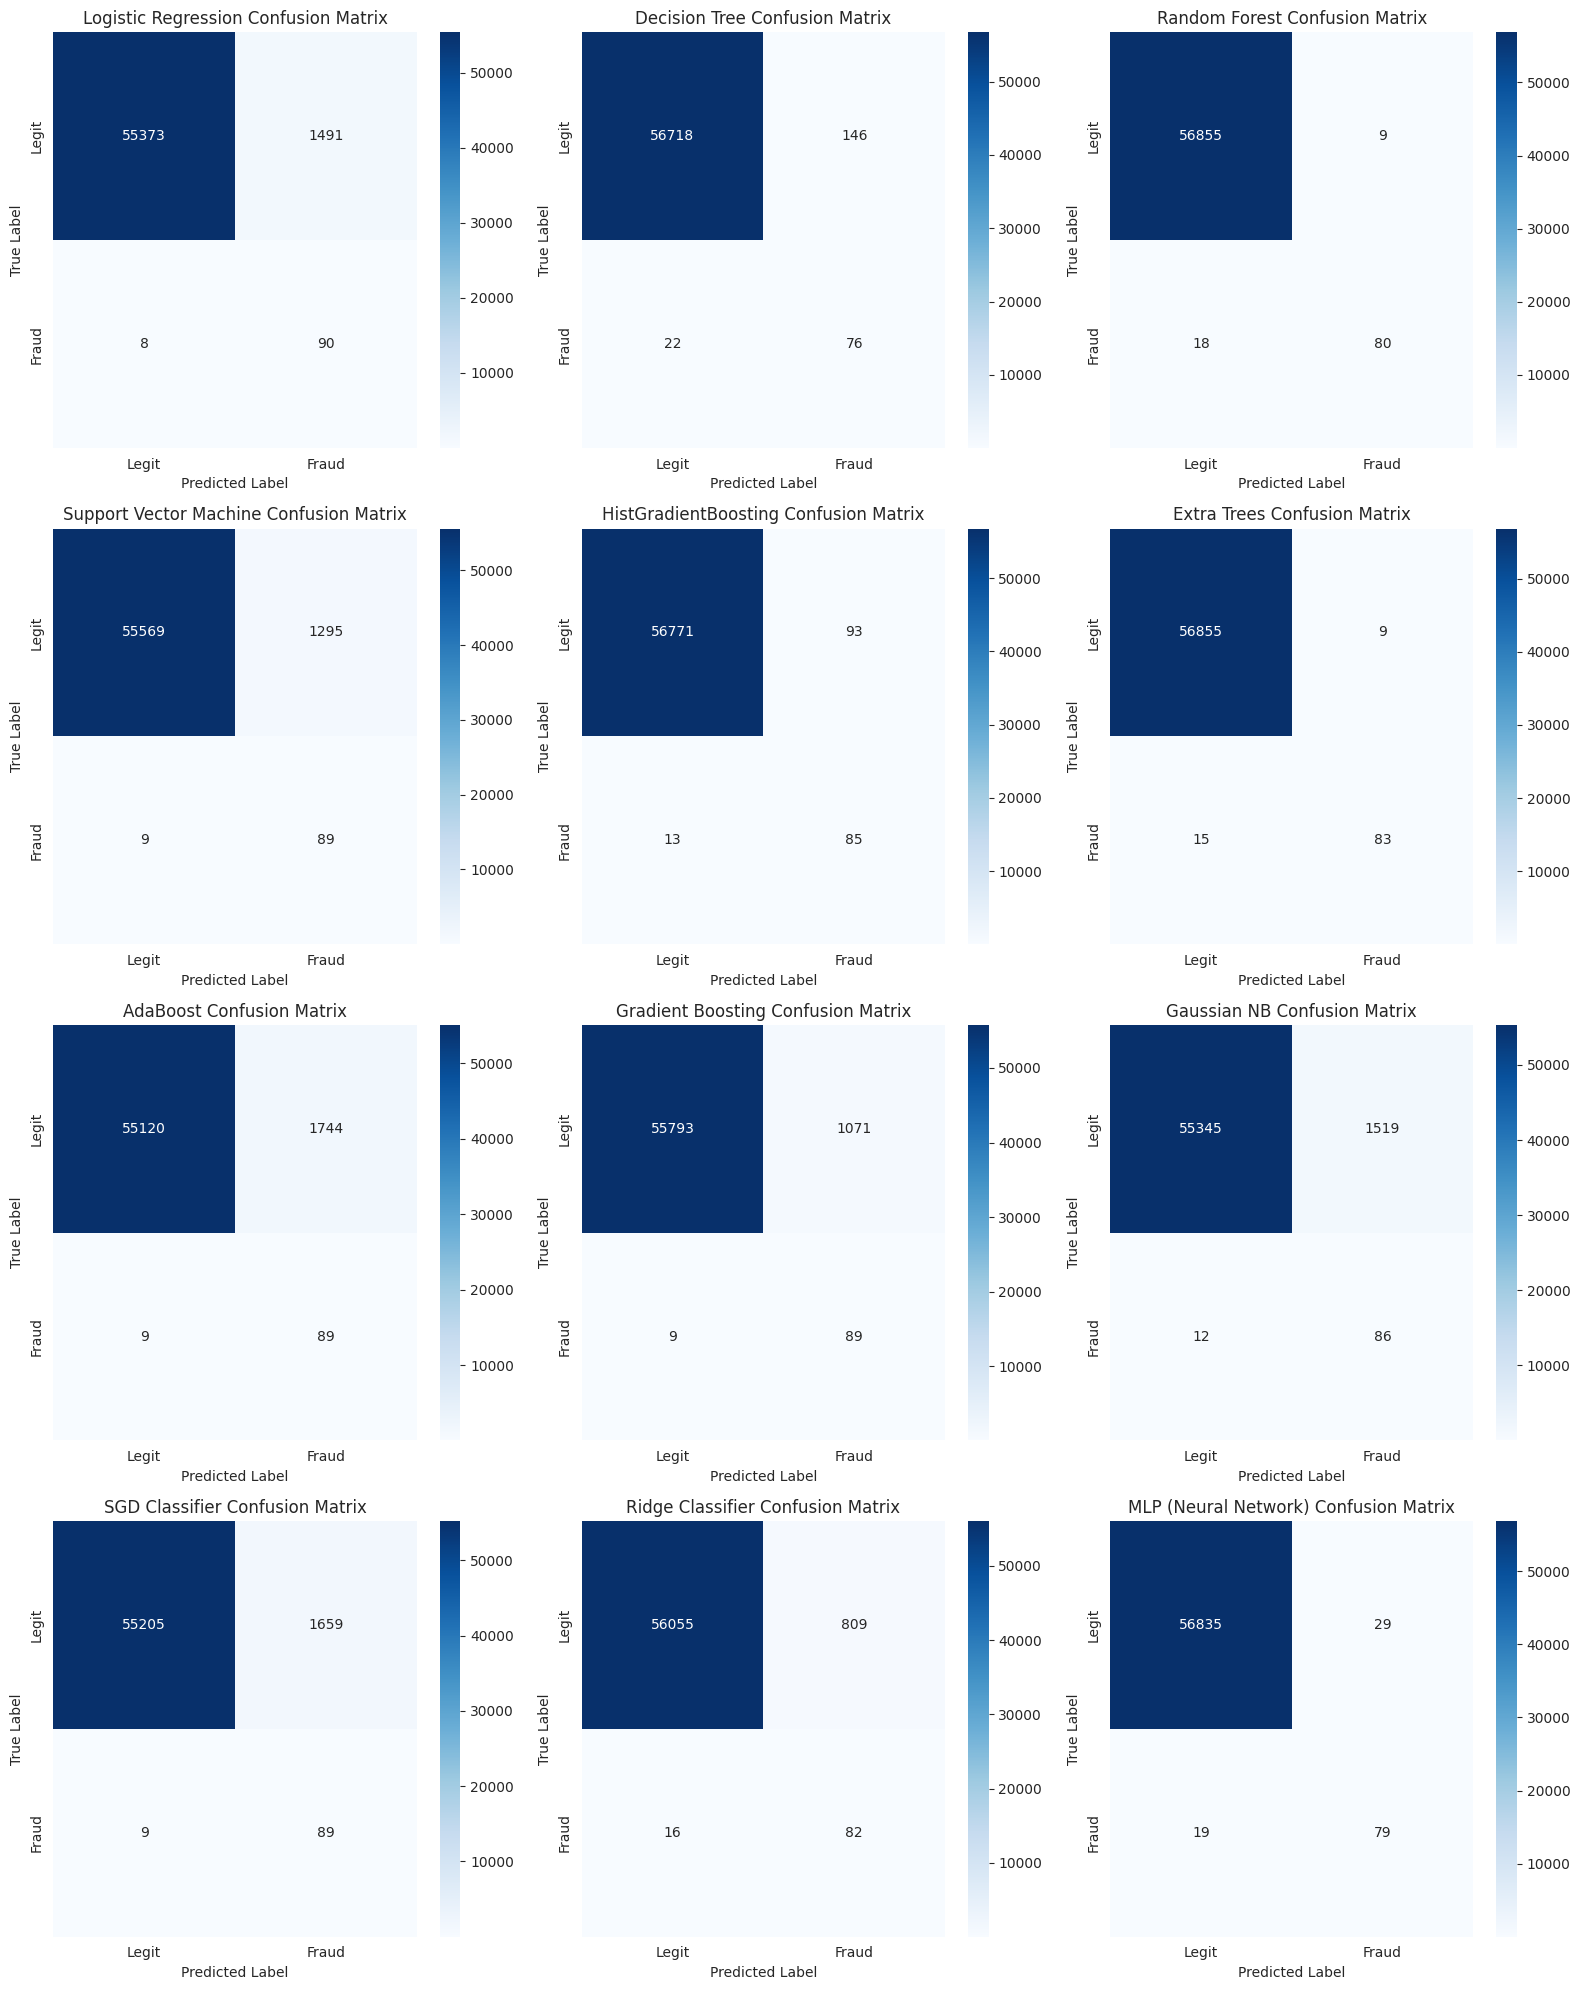

In [58]:
# Evaluation dictionary
results = {}

fig, axes = plt.subplots(4, 3, figsize=(16, 20))
axes = axes.flatten()

for i, (name, model) in enumerate(trained_models.items()):
    # Predict on unseen test set
    y_pred = model.predict(X_test)
    
    if hasattr(model, 'predict_proba'):
        y_scores = model.predict_proba(X_test)[:, 1]
    else:
        y_scores = model.decision_function(X_test)
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_scores)
    ap = average_precision_score(y_test, y_scores)
    
    results[name] = [acc, prec, rec, f1, mcc, roc_auc, ap]
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], 
                xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
    axes[i].set_title(f"{name} Confusion Matrix")
    axes[i].set_ylabel('True Label')
    axes[i].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

In [59]:
# Results Comparison
results_df = pd.DataFrame(results, index=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'MCC', 'ROC-AUC', 'Avg Precision']).T
print(results_df.sort_values(by='Avg Precision', ascending=False).round(4))

                        Accuracy  Precision  Recall  F1-Score     MCC  \
Extra Trees               0.9996     0.9022  0.8469    0.8737  0.8739   
Random Forest             0.9995     0.8989  0.8163    0.8556  0.8564   
MLP (Neural Network)      0.9992     0.7315  0.8061    0.7670  0.7675   
AdaBoost                  0.9692     0.0486  0.9082    0.0922  0.2061   
HistGradientBoosting      0.9981     0.4775  0.8673    0.6159  0.6428   
SGD Classifier            0.9707     0.0509  0.9082    0.0964  0.2112   
Support Vector Machine    0.9771     0.0643  0.9082    0.1201  0.2383   
Logistic Regression       0.9737     0.0569  0.9184    0.1072  0.2251   
Gradient Boosting         0.9810     0.0767  0.9082    0.1415  0.2609   
Decision Tree             0.9971     0.3423  0.7755    0.4750  0.5141   
Ridge Classifier          0.9855     0.0920  0.8367    0.1658  0.2747   
Gaussian NB               0.9731     0.0536  0.8776    0.1010  0.2131   

                        ROC-AUC  Avg Precision  
E

### Visualizing ROC and Precision-Recall Curves

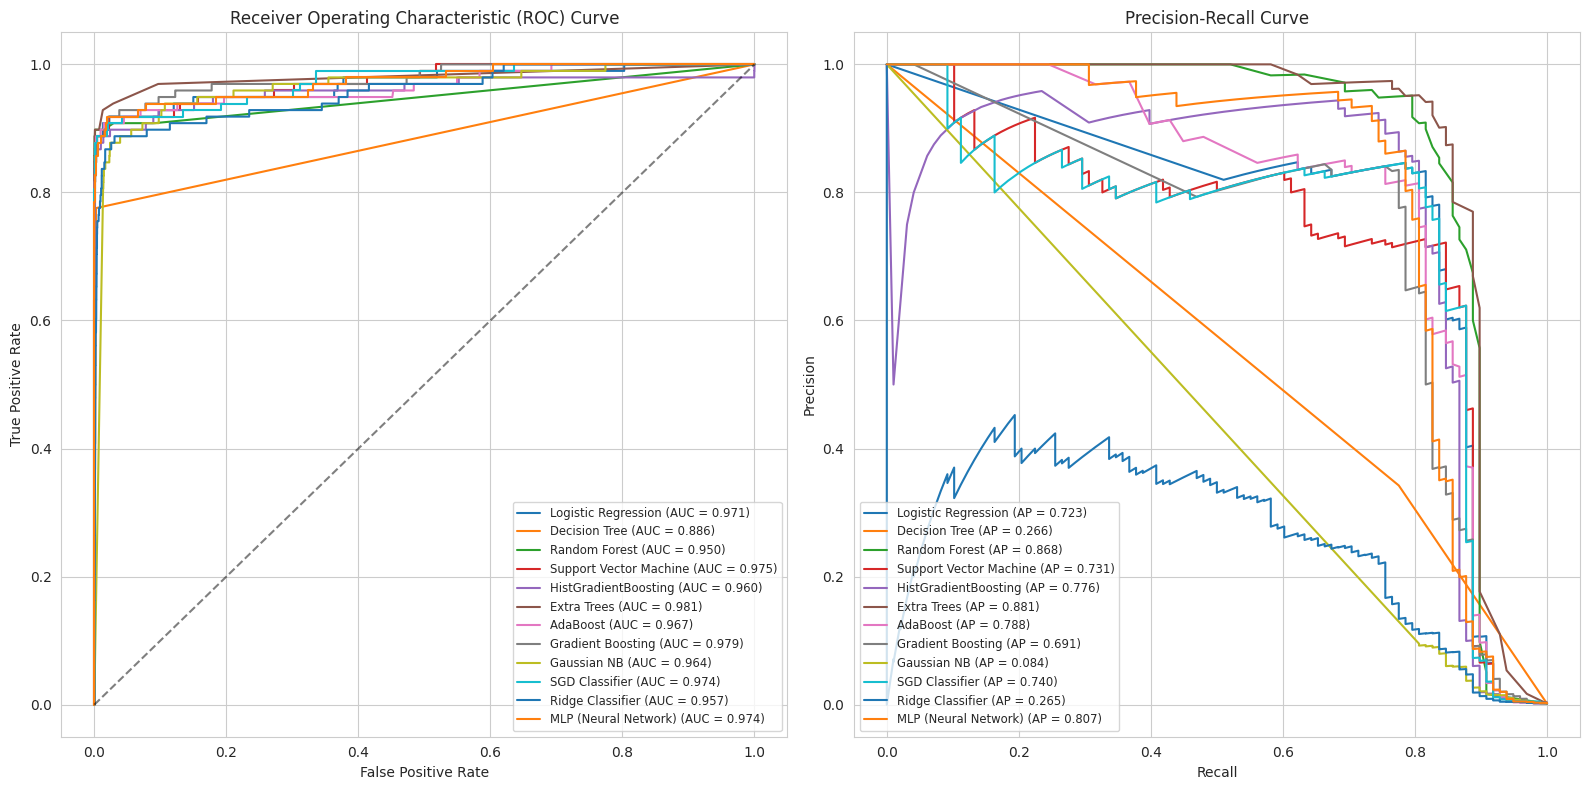

In [60]:
# Plot ROC and PR Curves for all models
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

for name, model in trained_models.items():
    if hasattr(model, 'predict_proba'):
        y_scores = model.predict_proba(X_test)[:, 1]
    else:
        y_scores = model.decision_function(X_test)
        
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_scores)
    roc_auc = roc_auc_score(y_test, y_scores)
    ax1.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')
    
    # PR Curve
    precisions, recalls, _ = precision_recall_curve(y_test, y_scores)
    ap = average_precision_score(y_test, y_scores)
    ax2.plot(recalls, precisions, label=f'{name} (AP = {ap:.3f})')

ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('Receiver Operating Characteristic (ROC) Curve')
ax1.legend(loc='lower right', fontsize='small')

ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve')
ax2.legend(loc='lower left', fontsize='small')

plt.tight_layout()
plt.show()

### Feature Importance Visualization
We display the feature importances (or absolute coefficients for linear models) for the top 10 features of each model. Note that some models (like HistGradientBoosting, GaussianNB, and MLP) do not provide native feature importances without expensive permutation techniques.

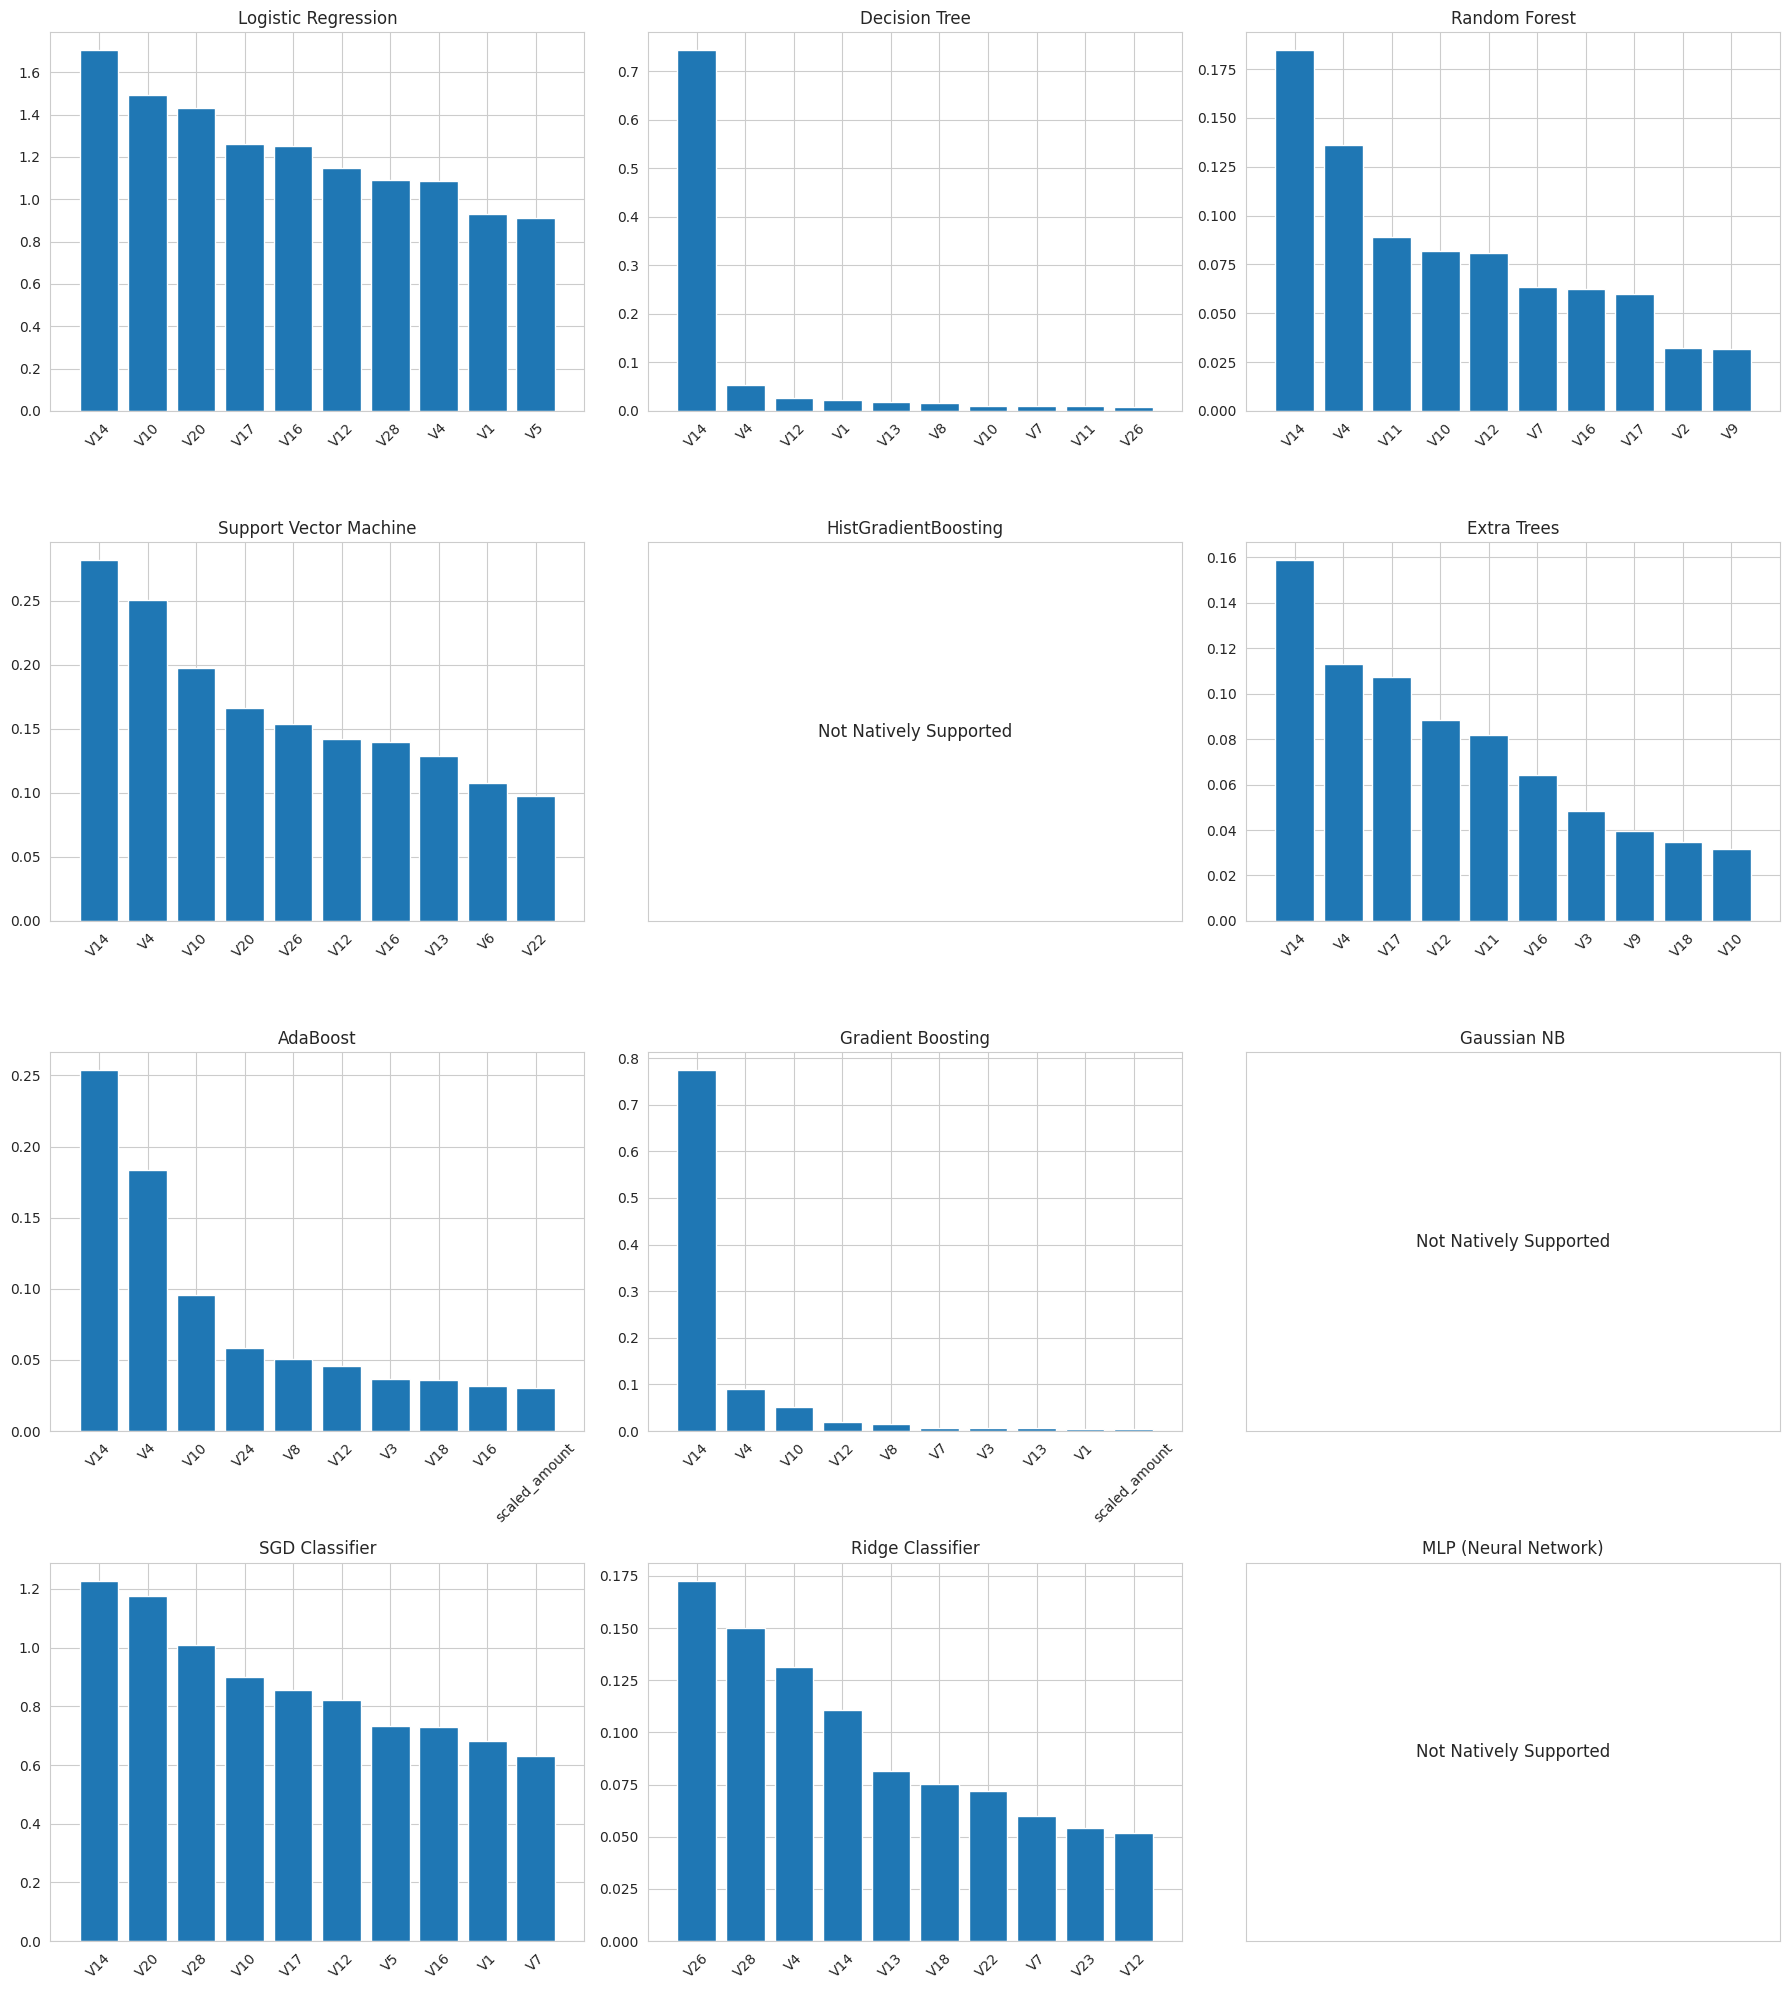

In [61]:
# Extract feature importances for all models
fig, axes = plt.subplots(4, 3, figsize=(18, 20))
axes = axes.flatten()
feature_names = X.columns

for i, (name, model) in enumerate(trained_models.items()):
    ax = axes[i]
    importances = None
    
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    elif hasattr(model, 'coef_'):
        importances = np.abs(model.coef_).flatten()
        
    if importances is not None:
        indices = np.argsort(importances)[::-1][:10] # Top 10
        ax.bar(range(10), importances[indices], align="center")
        ax.set_xticks(range(10))
        ax.set_xticklabels(feature_names[indices], rotation=45)
        ax.set_title(f"{name}")
        ax.set_xlim([-1, 10])
    else:
        ax.text(0.5, 0.5, "Not Natively Supported", ha='center', va='center', fontsize=12)
        ax.set_title(f"{name}")
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.show()

In [62]:
# Detailed Classification Report for each model
for name, model in trained_models.items():
    print(f"\n{'='*50}")
    print(f"Classification Report for {name}:")
    print(f"{'='*50}\n")
    print(classification_report(y_test, model.predict(X_test)))


Classification Report for Logistic Regression:

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962


Classification Report for Decision Tree:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.34      0.78      0.47        98

    accuracy                           1.00     56962
   macro avg       0.67      0.89      0.74     56962
weighted avg       1.00      1.00      1.00     56962


Classification Report for Random Forest:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.90      0.82      0.86        98

    accuracy                           1.00    